In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import random
from torchsummary import summary

In [3]:
## FINALLL - L.R change

In [4]:
"""
- Randomness controlled
- Transformations applied for train:
    transforms.RandomApply([transforms.CenterCrop(22), ], p=0.1),
    transforms.Resize((28, 28)),
    transforms.RandomRotation((-15., 15.), fill=0),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
- Transformations applied for test:
    transforms.ToTensor(),
    transforms.Normalize((0.1407,), (0.4081,))
- batch_size = 32
- NN Arch: 3 Convolutions -> Max pool -> 1*1 -> 1 Convolution -> F.C
    ----------------------------------------------------------------
            Layer (type)               Output Shape         Param #
    ================================================================
                Conv2d-1            [-1, 8, 26, 26]              80
                Conv2d-2           [-1, 16, 24, 24]           1,168
                Conv2d-3           [-1, 32, 22, 22]           4,640
                Conv2d-4            [-1, 8, 11, 11]             264
                Conv2d-5             [-1, 16, 9, 9]           1,168
                Linear-6                   [-1, 10]          12,970
    ================================================================
    Total params: 20,290
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(F.max_pool2d(x, 2))
        x = F.relu(self.conv6(x))
        x = F.relu(self.conv5(x))
        x = x.view(x.size(0),-1)
        x = self.fc1(x)
  - Best Train accuracy: 98.75
  - Best Test Accuracy: 98.70
  - 20k params
  - Analysis:
      - GAP is pretty decent but not good enough.
      - Train accuracy plateaus around 98.7 to 98.8
"""

'\n- Randomness controlled\n- Transformations applied for train:\n    transforms.RandomApply([transforms.CenterCrop(22), ], p=0.1),\n    transforms.Resize((28, 28)),\n    transforms.RandomRotation((-15., 15.), fill=0),\n    transforms.ToTensor(),\n    transforms.Normalize((0.1307,), (0.3081,)),\n- Transformations applied for test:\n    transforms.ToTensor(),\n    transforms.Normalize((0.1407,), (0.4081,))\n- batch_size = 32\n- NN Arch: 3 Convolutions -> Max pool -> 1*1 -> 1 Convolution -> F.C\n    ----------------------------------------------------------------\n            Layer (type)               Output Shape         Param #\n    ================================================================\n                Conv2d-1            [-1, 8, 26, 26]              80\n                Conv2d-2           [-1, 16, 24, 24]           1,168\n                Conv2d-3           [-1, 32, 22, 22]           4,640\n                Conv2d-4            [-1, 8, 11, 11]             264\n                

In [5]:
## Added GAP, Normalized the images with mean and std deviation from the whole dataset
## 96.63, 96.12 difference is decent again given the decrease in parameters as well.
## Not an Arch issue as the difference is not huge
"""
        Layer (type)               Output Shape         Param #
================================================================
            Conv2d-1            [-1, 8, 26, 26]              80
            Conv2d-2           [-1, 16, 24, 24]           1,168
            Conv2d-3           [-1, 32, 22, 22]           4,640
            Conv2d-4            [-1, 8, 11, 11]             264
            Conv2d-5             [-1, 16, 9, 9]           1,168
            Linear-6                   [-1, 10]             170
================================================================
Total params: 7,490
Trainable params: 7,490
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.25
Params size (MB): 0.03
Estimated Total Size (MB): 0.28
----------------------------------------------------------------
"""

'\n        Layer (type)               Output Shape         Param #\n================================================================\n            Conv2d-1            [-1, 8, 26, 26]              80\n            Conv2d-2           [-1, 16, 24, 24]           1,168\n            Conv2d-3           [-1, 32, 22, 22]           4,640\n            Conv2d-4            [-1, 8, 11, 11]             264\n            Conv2d-5             [-1, 16, 9, 9]           1,168\n            Linear-6                   [-1, 10]             170\n================================================================\nTotal params: 7,490\nTrainable params: 7,490\nNon-trainable params: 0\n----------------------------------------------------------------\nInput size (MB): 0.00\nForward/backward pass size (MB): 0.25\nParams size (MB): 0.03\nEstimated Total Size (MB): 0.28\n----------------------------------------------------------------\n'

In [6]:
## Added Batch Normalization after each convolution
## Overfitting (Gap is huge. Train is higher than test)
## Max train - 97.93, Max test - 95.70
## The overfitting issue arises because batch size is less and we are doing BN. meaning-> The batch is not a representative of the population
## The mean and std used while inference is from the whole one not the mini batch ones so if it is less then it will be noisy and that is why test is performing bad

"""
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
================================================================
            Conv2d-1            [-1, 8, 26, 26]              80
       BatchNorm2d-2            [-1, 8, 26, 26]              16
            Conv2d-3           [-1, 16, 24, 24]           1,168
       BatchNorm2d-4           [-1, 16, 24, 24]              32
            Conv2d-5           [-1, 32, 22, 22]           4,640
       BatchNorm2d-6           [-1, 32, 22, 22]              64
       BatchNorm2d-7           [-1, 32, 11, 11]              64
            Conv2d-8            [-1, 8, 11, 11]             264
       BatchNorm2d-9            [-1, 8, 11, 11]              16
           Conv2d-10             [-1, 16, 9, 9]           1,168
           Linear-11                   [-1, 10]             170
================================================================
Total params: 7,682
Trainable params: 7,682
Non-trainable params: 0
----------------------------------------------------------------
"""

'\n----------------------------------------------------------------\n        Layer (type)               Output Shape         Param #\n================================================================\n            Conv2d-1            [-1, 8, 26, 26]              80\n       BatchNorm2d-2            [-1, 8, 26, 26]              16\n            Conv2d-3           [-1, 16, 24, 24]           1,168\n       BatchNorm2d-4           [-1, 16, 24, 24]              32\n            Conv2d-5           [-1, 32, 22, 22]           4,640\n       BatchNorm2d-6           [-1, 32, 22, 22]              64\n       BatchNorm2d-7           [-1, 32, 11, 11]              64\n            Conv2d-8            [-1, 8, 11, 11]             264\n       BatchNorm2d-9            [-1, 8, 11, 11]              16\n           Conv2d-10             [-1, 16, 9, 9]           1,168\n           Linear-11                   [-1, 10]             170\n================================================================\nTotal params: 7,682

In [7]:
"""
120k params

"""

'\n120k params\n\n'

In [8]:
seed = 26
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:
def seed_worker(worker_id):
    worker_seed = 26
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(26)

In [10]:
# CUDA?
cuda = torch.cuda.is_available()
print("CUDA Available?", cuda)

CUDA Available? False


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
# Train data transformations
train_transforms = transforms.Compose([
    # transforms.RandomApply([transforms.CenterCrop(22), ], p=0.1), ## for 10% of the images, it will be cropped to 22*22 from the center. Basically shrinking with cutting
    # transforms.Resize((28, 28)), ## Resizing to original format
    transforms.RandomCrop(28, padding=2,fill=0), ## Adds the padding to all sides and then randomly select 28*28. Position of the nos vary
    transforms.RandomRotation((-5., 5.), fill=0), ## Rotates random b/w the degrees. For MNIST the background is black so fill=0
    transforms.ToTensor(),## Converts to 0.0 to 1.0
    transforms.Normalize((0.1307,), (0.3081,)), ## 0.1307 is the mean and 0.3081 is the Standard deviation for the train + test combined
    ])

# Test data transformations
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])

In [13]:
# ## For calculation of mean and Std deviation
# train_data = datasets.MNIST('../data', train=True, download=True)
# test_data = datasets.MNIST('../data', train=False, download=True)
# all_data = torch.cat([train_data.data, test_data.data], dim=0).float()/255.0 # scale to [0,1]

# # Compute mean and std
# mean = all_data.mean().item()
# std = all_data.std().item()

# print(f"MNIST Mean: {mean:.4f}, Std: {std:.4f}")

In [14]:
train_data = datasets.MNIST('../data', train=True, download=True, transform=train_transforms)
test_data = datasets.MNIST('../data', train=False, download=True, transform=test_transforms)

100%|██████████| 9.91M/9.91M [00:00<00:00, 39.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.08MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.73MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.83MB/s]


In [15]:
batch_size = 64

kwargs_train = {'batch_size': batch_size, 'shuffle': True, 'worker_init_fn': seed_worker, 'pin_memory': True if cuda else False, 'generator':g}
kwargs_test = {'batch_size': batch_size, 'shuffle': False, 'worker_init_fn': seed_worker, 'pin_memory': True if cuda else False, 'generator':g}

test_loader = torch.utils.data.DataLoader(test_data, **kwargs_train)
train_loader = torch.utils.data.DataLoader(train_data, **kwargs_test)

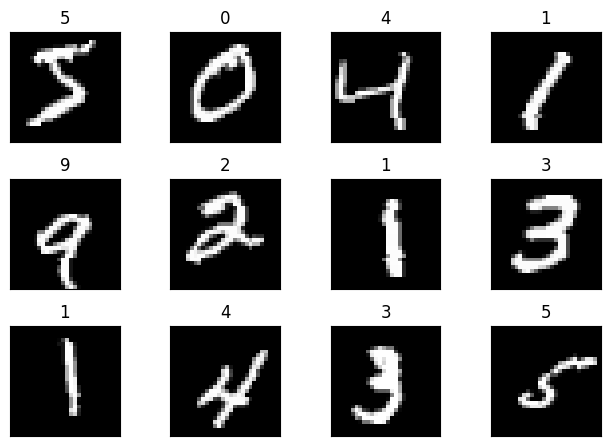

In [16]:
import matplotlib.pyplot as plt

batch_data, batch_label = next(iter(train_loader))

fig = plt.figure()

for i in range(12):
  plt.subplot(3,4,i+1)
  plt.tight_layout()
  plt.imshow(batch_data[i].squeeze(0), cmap='gray')
  plt.title(batch_label[i].item())
  plt.xticks([])
  plt.yticks([])

In [17]:
class Net(nn.Module):
    #This defines the structure of the NN.
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(p=0.1)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(16, 8, kernel_size=1)
        self.fc1 = nn.Linear(32, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(F.max_pool2d(x, 2))
        x = F.relu(self.conv6(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.adaptive_avg_pool2d(x, 1)
        x = torch.flatten(x, 1)
        # x = F.dropout(x, p=0.2, training=self.training)
        x = self.fc1(x)
        # return F.log_softmax(x, dim=1)
        return x ## Contains raw logits - Score per class

In [18]:
model = Net().to(device)
tot_params = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        tot_params+=param.numel()
        print(f"{name}: {param.numel()} parameters")


conv1.weight: 72 parameters
conv1.bias: 8 parameters
conv2.weight: 1152 parameters
conv2.bias: 16 parameters
conv3.weight: 1152 parameters
conv3.bias: 16 parameters
conv4.weight: 4608 parameters
conv4.bias: 32 parameters
conv6.weight: 128 parameters
conv6.bias: 8 parameters
fc1.weight: 320 parameters
fc1.bias: 10 parameters


In [19]:
print(tot_params)

7522


In [20]:
summary(model,input_size = (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 28, 28]              80
            Conv2d-2           [-1, 16, 28, 28]           1,168
            Conv2d-3            [-1, 8, 14, 14]             136
            Conv2d-4           [-1, 16, 14, 14]           1,168
            Conv2d-5           [-1, 32, 14, 14]           4,640
            Linear-6                   [-1, 10]             330
Total params: 7,522
Trainable params: 7,522
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.23
Params size (MB): 0.03
Estimated Total Size (MB): 0.26
----------------------------------------------------------------


In [21]:
# Data to plot accuracy and loss graphs
train_losses = []
test_losses = []
train_acc = []
test_acc = []
tr_te_diff = []

test_incorrect_pred = {'images': [], 'ground_truths': [], 'predicted_vals': []}

In [22]:

from tqdm import tqdm

def GetCorrectPredCount(pPrediction, pLabels):
  return pPrediction.argmax(dim=1).eq(pLabels).sum().item()

def train(model, device, train_loader, optimizer, criterion):
  model.train()
  pbar = tqdm(train_loader)

  train_loss = 0
  correct = 0
  processed = 0

  for batch_idx, (data, target) in enumerate(pbar):
    data, target = data.to(device), target.to(device)
    optimizer.zero_grad()

    # Predict
    pred = model(data)

    # Calculate loss
    loss = criterion(pred, target)
    train_loss+=loss.item()


    # Backpropagation
    loss.backward()
    optimizer.step()

    correct += GetCorrectPredCount(pred, target)
    processed += len(data)

    pbar.set_description(desc= f'Train: Loss={loss.item():0.4f} Batch_id={batch_idx} Accuracy={100*correct/processed:0.2f}')

  train_acc.append(100*correct/processed)
  train_losses.append(train_loss/len(train_loader))

def test(model, device, test_loader, criterion):
    model.eval()

    test_loss = 0
    correct = 0

    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(test_loader):
            data, target = data.to(device), target.to(device)

            output = model(data)
            test_loss += criterion(output, target).item()  # sum up batch loss

            correct += GetCorrectPredCount(output, target)


    test_loss /= len(test_loader.dataset)
    test_acc.append(100. * correct / len(test_loader.dataset))
    test_losses.append(test_loss)

    print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    print("Gap b/w train and test: {:.2f}\n".format(abs(train_acc[-1] - test_acc[-1])))


In [23]:
# for i in range(0, len(train_acc)):
#   tr_te_diff.append(train_acc[i] - test_acc[i])

In [24]:
import warnings
warnings.filterwarnings('ignore')

In [25]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss(reduction="mean")

num_epochs = 15

for epoch in range(1, num_epochs+1):
  print(f'Epoch {epoch}')
  train(model, device, train_loader, optimizer, criterion)
  test(model, device, test_loader, criterion)
  scheduler.step()

Epoch 1


Train: Loss=1.2517 Batch_id=857 Accuracy=35.92:  91%|█████████▏| 858/938 [00:40<00:03, 21.18it/s]


KeyboardInterrupt: 

Text(0.5, 1.0, 'Test Accuracy')

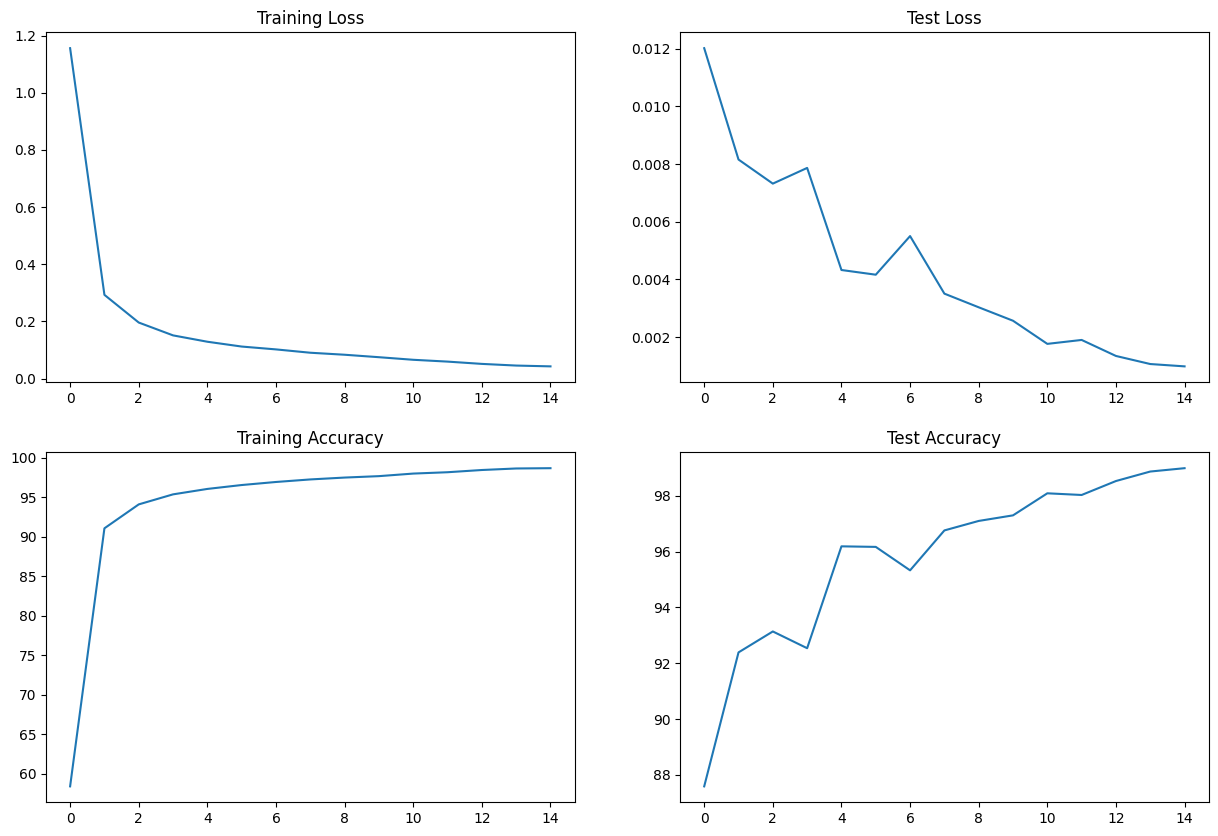

In [47]:
fig, axs = plt.subplots(2,2,figsize=(15,10))
axs[0, 0].plot(train_losses)
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc)
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(test_losses)
axs[0, 1].set_title("Test Loss")
axs[1, 1].plot(test_acc)
axs[1, 1].set_title("Test Accuracy")